In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler

In [ ]:
df = pd.read_excel("Dump Dataset.xlsx")
df_raw = df.copy()

In [ ]:
df.head()

,Merchant Name,Courier Partner,Channel Name,Payment Mode,Zone,Created at,Status,Pickup Pincode,Pickup City,Pickup State,...,Shipment Breadth,Shipment Height,Shipment Weight,Invoice Date,COD Value,Invoice Value,Order Date,Delivery Date,Min Tat,Max Tat
0,Client 1,ATS Surface,WMS,COD,ROI,2025-10-01 23:54:42,CANCELLED_ORDER,410501,Pune,Maharashtra,...,10.0,10.0,1000.0,2025-10-01 23:54:42,575.0,575.000000,2025-10-01,,5,7
1,Client 2,Delhivery Surface,WMS,PREPAID,ROI,2025-10-01 23:53:04,DELIVERED,201301,Noida,Uttar Pradesh,...,5.0,5.0,500.0,2025-10-01 23:53:04,0.0,303.359985,2025-10-01,2025-10-09 16:59:21,5,6
2,Client 3,ATS Surface,ATS_B2C_SURFACE,PREPAID,ROI,2025-10-01 23:49:22,CANCELLED_ORDER,382424,Ahmedabad,Gujrat,...,5.0,5.0,100.0,2025-10-01 23:49:22,0.0,199.000000,2025-10-01,,5,7
3,Client 2,Delhivery Surface,WMS,PREPAID,LOCAL,2025-10-01 23:48:49,DELIVERED,201301,Noida,Uttar Pradesh,...,5.0,5.0,300.0,2025-10-01 23:48:49,0.0,314.369995,2025-10-01,2025-10-05 12:36:07,1,2
4,Client 3,ATS Surface,ATS_B2C_SURFACE,PREPAID,ROI,2025-10-01 23:35:06,CANCELLED_ORDER,382424,Ahmedabad,Gujrat,...,5.0,5.0,100.0,2025-10-01 23:35:06,0.0,199.000000,2025-10-01,,5,7


PreProcessing

In [ ]:
df.dtypes

Merchant Name               object
Courier Partner             object
Channel Name                object
Payment Mode                object
Zone                        object
Created at          datetime64[ns]
Status                      object
Pickup Pincode               int64
Pickup City                 object
Pickup State                object
Pickup Country              object
Drop Pincode                 int64
Drop City                   object
Drop State                  object
Drop Country                object
Total Quantity               int64
Shipment Length            float64
Shipment Breadth           float64
Shipment Height            float64
Shipment Weight            float64
Invoice Date        datetime64[ns]
COD Value                  float64
Invoice Value              float64
Order Date          datetime64[ns]
Delivery Date               object
Min Tat                     object
Max Tat                     object
dtype: object

In [ ]:
df.columns = df.columns.str.strip()

Identifies all date-related columns in the dataset and stores their names in a list called date_cols.

Loops through each of these columns one by one.

Converts each column to a proper datetime format using pandas’ to_datetime() function.

Any value that cannot be interpreted as a valid date is automatically converted to NaT (Not a Time).

In [ ]:
date_cols = ['Created at', 'Order Date', 'Delivery Date', 'Invoice Date']
for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')


C:\Users\bharg\AppData\Local\Temp\ipykernel_28064\567794102.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[col] = pd.to_datetime(df[col], errors='coerce')


Identifies all columns that are supposed to be numeric—quantities, dimensions, weights, monetary values, and promised delivery times.

Iterates through each column in the list.

Forces pandas to interpret the column as numeric (integer or float).

Any value that cannot be converted into a number (for example, text, blanks, or malformed entries) is converted to NaN.

In [ ]:
num_cols = [
    'Total Quantity',
    'Shipment Length', 'Shipment Breadth', 'Shipment Height',
    'Shipment Weight',
    'COD Value', 'Invoice Value',
    'Min Tat', 'Max Tat'
]

for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

Identifies categorical columns that represent labels or groups (status, zone, channel, payment type, courier).

Converts every value to a string using astype(str).

Removes leading and trailing spaces using .str.strip().

Converts all text to uppercase using .str.upper().

In [ ]:
cat_cols = ['Status', 'Zone', 'Channel Name', 'Payment Mode', 'Courier Partner']

for col in cat_cols:
    df[col] = df[col].astype(str).str.strip().str.upper()


In [ ]:
df['Status'].value_counts()

Status
DELIVERED               217137
RTO_DELIVERED            40332
CANCELLED_ORDER           5686
LOST                       506
RTO_INTRANSIT              309
RTO_FAILED                  76
RTO_OUT_FOR_DELIVERY        52
RTO_REQUESTED               28
RTO                         22
INTRANSIT                   10
AWB_REGISTERED               2
RTO_SHIPMENT_DELAY           2
SHIPMENT_DELAYED             2
SHIPMENT_HELD                2
PICKED_UP                    2
ORDER_PLACED                 1
OUT_FOR_DELIVERY             1
OUT_FOR_PICKUP               1
Name: count, dtype: int64

Defines which order statuses count as a completed delivery:

    DELIVERED: normal successful delivery

    RTO_DELIVERED: delivered after a return-to-origin cycle

Creates a new column called Delivery Completion.

For each row:

    If the order’s Status is in the list of delivered statuses → mark it as COMPLETED

    Otherwise → mark it as NOT_COMPLETED

In [ ]:
delivered_statuses = ['DELIVERED', 'RTO DELIVERED']

df['Delivery Completion'] = df['Status'].apply(
    lambda x: 'COMPLETED' if x in delivered_statuses else 'NOT_COMPLETED'
)

Subtracts the order creation timestamp from the delivery timestamp for each order.

The subtraction produces a time difference (a timedelta object).

.dt.days extracts the difference in number of days.

The result is stored in a new column called Actual Delivery Days.

In [ ]:
df['Actual Delivery Days'] = (
    df['Delivery Date'] - df['Created at']
).dt.days

Takes the three physical dimensions of each shipment:

    Length

    Breadth

    Height

Multiplies them together to compute the total three-dimensional size of the shipment.

Stores the result in a new column called Shipment Volume.

In [ ]:
df['Shipment Volume'] = (
    df['Shipment Length'] *
    df['Shipment Breadth'] *
    df['Shipment Height']
)

Extracts the day of the week (Monday, Tuesday, etc.) from the order creation timestamp and stores it in a new column called Order Day.

Extracts the month number (1–12) from the order creation timestamp and stores it in a new column called Order Month.

In [ ]:
df['Order Day'] = df['Created at'].dt.day_name()
df['Order Month'] = df['Created at'].dt.month

Checks whether the calculated delivery duration is logically invalid:

    Less than 0 days (delivery before order creation)

    Greater than 60 days (extremely long for typical e-commerce logistics)

Creates a boolean flag called Invalid Delivery Duration:

    True → delivery duration looks suspicious or invalid

    False → delivery duration falls within a reasonable range

In [ ]:
df['Invalid Delivery Duration'] = (
    (df['Actual Delivery Days'] < 0) |
    (df['Actual Delivery Days'] > 60)
)

EDA

In [ ]:
df.shape

(264171, 33)

In [ ]:
df.dtypes

Merchant Name                        object
Courier Partner                      object
Channel Name                         object
Payment Mode                         object
Zone                                 object
Created at                   datetime64[ns]
Status                               object
Pickup Pincode                        int64
Pickup City                          object
Pickup State                         object
Pickup Country                       object
Drop Pincode                          int64
Drop City                            object
Drop State                           object
Drop Country                         object
Total Quantity                        int64
Shipment Length                     float64
Shipment Breadth                    float64
Shipment Height                     float64
Shipment Weight                     float64
Invoice Date                 datetime64[ns]
COD Value                           float64
Invoice Value                   

In [ ]:
df.head()

,Merchant Name,Courier Partner,Channel Name,Payment Mode,Zone,Created at,Status,Pickup Pincode,Pickup City,Pickup State,...,Order Date,Delivery Date,Min Tat,Max Tat,Delivery Completion,Actual Delivery Days,Shipment Volume,Order Day,Order Month,Invalid Delivery Duration
0,Client 1,ATS SURFACE,WMS,COD,ROI,2025-10-01 23:54:42,CANCELLED_ORDER,410501,Pune,Maharashtra,...,2025-10-01,NaT,5.0,7.0,NOT_COMPLETED,NaN,2000.0,Wednesday,10,False
1,Client 2,DELHIVERY SURFACE,WMS,PREPAID,ROI,2025-10-01 23:53:04,DELIVERED,201301,Noida,Uttar Pradesh,...,2025-10-01,2025-10-09 16:59:21,5.0,6.0,COMPLETED,7.0,125.0,Wednesday,10,False
2,Client 3,ATS SURFACE,ATS_B2C_SURFACE,PREPAID,ROI,2025-10-01 23:49:22,CANCELLED_ORDER,382424,Ahmedabad,Gujrat,...,2025-10-01,NaT,5.0,7.0,NOT_COMPLETED,NaN,250.0,Wednesday,10,False
3,Client 2,DELHIVERY SURFACE,WMS,PREPAID,LOCAL,2025-10-01 23:48:49,DELIVERED,201301,Noida,Uttar Pradesh,...,2025-10-01,2025-10-05 12:36:07,1.0,2.0,COMPLETED,3.0,125.0,Wednesday,10,False
4,Client 3,ATS SURFACE,ATS_B2C_SURFACE,PREPAID,ROI,2025-10-01 23:35:06,CANCELLED_ORDER,382424,Ahmedabad,Gujrat,...,2025-10-01,NaT,5.0,7.0,NOT_COMPLETED,NaN,250.0,Wednesday,10,False


In [ ]:
df['Status'].value_counts()

Status
DELIVERED               217137
RTO_DELIVERED            40332
CANCELLED_ORDER           5686
LOST                       506
RTO_INTRANSIT              309
RTO_FAILED                  76
RTO_OUT_FOR_DELIVERY        52
RTO_REQUESTED               28
RTO                         22
INTRANSIT                   10
AWB_REGISTERED               2
RTO_SHIPMENT_DELAY           2
SHIPMENT_DELAYED             2
SHIPMENT_HELD                2
PICKED_UP                    2
ORDER_PLACED                 1
OUT_FOR_DELIVERY             1
OUT_FOR_PICKUP               1
Name: count, dtype: int64

In [ ]:
df['Delivery Completion'].value_counts(normalize=True) * 100

Delivery Completion
COMPLETED        82.195623
NOT_COMPLETED    17.804377
Name: proportion, dtype: float64

This line computes the percentage of missing values in each column and sorts the results from most missing to least missing.

In [ ]:
(df.isnull().mean() * 100).sort_values(ascending=False)

Actual Delivery Days         17.803998
Delivery Date                17.803998
Max Tat                       1.500543
Min Tat                       1.500543
Drop City                     0.144225
Drop Country                  0.140061
Drop State                    0.004164
Merchant Name                 0.000000
Courier Partner               0.000000
Pickup City                   0.000000
Pickup Pincode                0.000000
Status                        0.000000
Pickup State                  0.000000
Created at                    0.000000
Channel Name                  0.000000
Payment Mode                  0.000000
Zone                          0.000000
Shipment Length               0.000000
Total Quantity                0.000000
Pickup Country                0.000000
Drop Pincode                  0.000000
Invoice Date                  0.000000
Shipment Breadth              0.000000
Shipment Weight               0.000000
Shipment Height               0.000000
Order Date               

The missing value analysis shows that most missingness is structural and tied to order lifecycle outcomes, particularly undelivered orders. Core operational and shipment attributes are nearly complete, indicating high data reliability for exploratory and modeling analysis.

In [ ]:
pd.crosstab(
    df['Status'],
    df['Delivery Date'].isna(),
    normalize='index'
) * 100


Delivery Date,False,True
Status,,
AWB_REGISTERED,0.000000,100.000000
CANCELLED_ORDER,0.000000,100.000000
DELIVERED,100.000000,0.000000
INTRANSIT,0.000000,100.000000
LOST,0.000000,100.000000
ORDER_PLACED,0.000000,100.000000
OUT_FOR_DELIVERY,0.000000,100.000000
OUT_FOR_PICKUP,0.000000,100.000000
PICKED_UP,0.000000,100.000000


Cross-tabulation revealed that although RTO_DELIVERED sounds like a completed delivery, it predominantly lacks a customer delivery date. This indicates that the status represents return-to-origin completion rather than customer delivery. Accordingly, only orders with status DELIVERED are treated as completed for delivery-time and delay analysis.

In [ ]:
delivered_statuses = ['DELIVERED']

In [ ]:
df['Delivery Completion'] = df['Status'].apply(
    lambda x: 'COMPLETED' if x == 'DELIVERED' else 'NOT_COMPLETED'
)

We created a subset of the data containing only customer-delivered orders. This ensures that delivery duration and delay analysis are performed only where a delivery date exists and the concept of delay is meaningful.

In [ ]:
completed = df[df['Delivery Completion'] == 'COMPLETED']

In [ ]:
completed['Actual Delivery Days'].describe()

count    217137.000000
mean          3.754795
std           2.554863
min           0.000000
25%           2.000000
50%           3.000000
75%           5.000000
max          63.000000
Name: Actual Delivery Days, dtype: float64

In [ ]:
completed.shape
completed['Status'].value_counts()

Status
DELIVERED    217137
Name: count, dtype: int64

<Axes: >

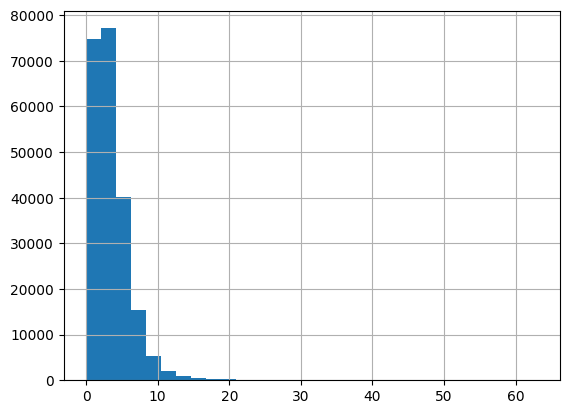

In [ ]:
completed['Actual Delivery Days'].hist(bins=30)

In [ ]:
(completed['Actual Delivery Days'] > completed['Max Tat']).mean() * 100


np.float64(19.91461611793476)

This scatter plot compares promised maximum delivery time with actual delivery duration for delivered orders. The vertical bands reflect discrete service-level commitments, while the vertical spread within each band highlights delivery variability. Points above the implied diagonal represent delayed orders, showing that delays are common and increase in variability as promised delivery windows grow

<Axes: xlabel='Max Tat', ylabel='Actual Delivery Days'>

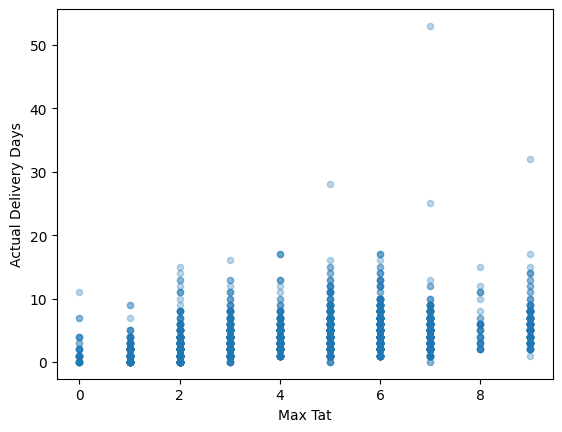

In [ ]:
completed[['Actual Delivery Days','Max Tat']].sample(5000).plot.scatter(
    x='Max Tat', y='Actual Delivery Days', alpha=0.3
)


Zone-wise completion analysis shows consistently high delivery success rates across the network, with all major zones exceeding 96% completion. While metropolitan zones show slightly higher non-completion, the overall differences are small, indicating that the primary operational challenge lies in delivery timeliness rather than delivery failure.

In [ ]:
pd.crosstab(
    df['Zone'],
    df['Delivery Completion'],
    normalize='index'
) * 100


Delivery Completion,COMPLETED,NOT_COMPLETED
Zone,,
,83.980827,16.019173
LOCAL,84.671062,15.328938
METROS,88.148074,11.851926
REGIONAL,84.403750,15.596250
ROI,80.359586,19.640414
SPECIAL,80.497531,19.502469


Zone-wise delay analysis reveals substantial differences in delivery timeliness. Metropolitan deliveries experience the highest delay rate at nearly 30%, while special-handling shipments perform best. Although delivery completion is high across all zones, timeliness varies significantly, highlighting zone as a critical driver of delivery delays.

In [ ]:
completed.assign(
    Delayed = completed['Actual Delivery Days'] > completed['Max Tat']
).groupby('Zone')['Delayed'].mean() * 100

Zone
             0.000000
LOCAL       24.243223
METROS      32.750056
REGIONAL    17.030583
ROI         18.645461
SPECIAL     14.170009
Name: Delayed, dtype: float64

In [ ]:
df['Shipment Weight'].describe()


count    264171.000000
mean        879.028774
std        2622.249303
min           0.080000
25%         100.000000
50%         350.000000
75%         980.000000
max      503500.000000
Name: Shipment Weight, dtype: float64

Shipment weight was discretized into operationally meaningful buckets to simplify exploratory analysis and enable comparison of delay behavior across different weight ranges

In [ ]:
df['Weight Bucket'] = pd.cut(
    df['Shipment Weight'],
    bins=[0,1,5,10,20,50,100,1000],
    right=False
)



In [ ]:
df['Weight Bucket'].value_counts()

Weight Bucket
[100, 1000)    172933
[1, 5)           5558
[20, 50)         5553
[0, 1)           5346
[50, 100)        5158
[10, 20)         3433
[5, 10)           860
Name: count, dtype: int64

In [ ]:
completed = df[df['Delivery Completion'] == 'COMPLETED']

Delay rates vary across shipment weight ranges, with lighter shipments exhibiting lower delay probabilities and mid-weight shipments showing higher risk. The relationship is non-linear, suggesting that shipment weight interacts with other operational factors such as zone and courier.

In [ ]:
completed.assign(
    Delayed = completed['Actual Delivery Days'] > completed['Max Tat']
).groupby('Weight Bucket')['Delayed'].mean() * 100

C:\Users\bharg\AppData\Local\Temp\ipykernel_28064\2940228363.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ).groupby('Weight Bucket')['Delayed'].mean() * 100


Weight Bucket
[0, 1)         10.238706
[1, 5)         15.912003
[5, 10)        26.602564
[10, 20)       24.326169
[20, 50)       12.266667
[50, 100)      16.714150
[100, 1000)    18.260647
Name: Delayed, dtype: float64

In [ ]:
df['Shipment Weight'].describe(percentiles=[.5,.75,.9,.95,.99])


count    264171.000000
mean        879.028774
std        2622.249303
min           0.080000
50%         350.000000
75%         980.000000
90%        2780.000000
95%        3000.000000
99%        7600.000000
max      503500.000000
Name: Shipment Weight, dtype: float64

In [ ]:
df['Shipment Weight'].nlargest(20)

64458     503500.0
30812     500950.0
43304     500500.0
97216     500000.0
9483      251830.0
169704    250220.0
163483    121350.0
1191      100000.0
51664     100000.0
163004    100000.0
52211      71400.0
52213      71400.0
119330     45600.0
16048      44400.0
252080     40000.0
252088     40000.0
252090     40000.0
252091     40000.0
196252     39600.0
120796     37000.0
Name: Shipment Weight, dtype: float64

In [ ]:
(df['Shipment Weight'] <= 0).sum(), df['Shipment Weight'].isna().sum()


(np.int64(0), np.int64(0))

To address skewness in shipment weight, we used quantile-based binning, which ensures each bucket contains a similar number of observations. This reveals a clear and monotonic increase in delay probability as shipment weight increases, confirming weight as a key driver of delivery delays.

In [ ]:
completed['Weight Q'] = pd.qcut(completed['Shipment Weight'], q=10, duplicates='drop')
delay_by_q = completed.assign(
    Delayed = completed['Actual Delivery Days'] > completed['Max Tat']
).groupby('Weight Q')['Delayed'].mean() * 100

delay_by_q

C:\Users\bharg\AppData\Local\Temp\ipykernel_28064\1099605132.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  completed['Weight Q'] = pd.qcut(completed['Shipment Weight'], q=10, duplicates='drop')
C:\Users\bharg\AppData\Local\Temp\ipykernel_28064\1099605132.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ).groupby('Weight Q')['Delayed'].mean() * 100


Weight Q
(0.079, 80.0]         15.389481
(80.0, 100.0]         12.221383
(100.0, 210.0]        22.192615
(210.0, 350.0]        19.286962
(350.0, 480.0]        23.085720
(480.0, 720.0]        22.342273
(720.0, 1200.0]       21.697817
(1200.0, 2650.0]      24.660526
(2650.0, 503500.0]    27.882223
Name: Delayed, dtype: float64

While shipment volume is associated with delivery delays, the relationship is less consistent than for shipment weight. Extremely bulky shipments show higher delay risk, but overall weight appears to be a stronger and more stable predictor of delays than volume

In [ ]:
completed['Volume Q'] = pd.qcut(
    completed['Shipment Volume'], q=10, duplicates='drop'
)

completed.assign(
    Delayed = completed['Actual Delivery Days'] > completed['Max Tat']
).groupby('Volume Q')['Delayed'].mean() * 100


C:\Users\bharg\AppData\Local\Temp\ipykernel_28064\2355158996.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  completed['Volume Q'] = pd.qcut(
C:\Users\bharg\AppData\Local\Temp\ipykernel_28064\2355158996.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ).groupby('Volume Q')['Delayed'].mean() * 100


Volume Q
(0.0, 50.0]           17.311478
(50.0, 100.0]         11.011022
(100.0, 234.0]        20.602347
(234.0, 900.0]        18.938234
(900.0, 1000.0]       32.338998
(1000.0, 1824.0]      20.703030
(1824.0, 3780.0]      17.573901
(3780.0, 7161.0]      22.817538
(7161.0, 357000.0]    22.269625
Name: Delayed, dtype: float64

Interaction analysis shows that shipment weight and delivery zone jointly influence delay risk. Metropolitan zones exhibit high baseline delays across all weight levels, while heavier shipments significantly increase delay probability across all zones. This confirms that delay drivers are not additive but interactive in nature

In [ ]:
completed.assign(
    Delayed = completed['Actual Delivery Days'] > completed['Max Tat']
).groupby(['Zone','Weight Q'])['Delayed'].mean()

C:\Users\bharg\AppData\Local\Temp\ipykernel_28064\2307433735.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ).groupby(['Zone','Weight Q'])['Delayed'].mean()


Zone      Weight Q          
          (0.079, 80.0]         0.000000
          (80.0, 100.0]         0.000000
          (100.0, 210.0]        0.000000
          (210.0, 350.0]        0.000000
          (350.0, 480.0]        0.000000
          (480.0, 720.0]        0.000000
          (720.0, 1200.0]       0.000000
          (1200.0, 2650.0]      0.000000
          (2650.0, 503500.0]    0.000000
LOCAL     (0.079, 80.0]         0.186851
          (80.0, 100.0]         0.187530
          (100.0, 210.0]        0.237830
          (210.0, 350.0]        0.196053
          (350.0, 480.0]        0.178378
          (480.0, 720.0]        0.208288
          (720.0, 1200.0]       0.199383
          (1200.0, 2650.0]      0.321720
          (2650.0, 503500.0]    0.387922
METROS    (0.079, 80.0]         0.257945
          (80.0, 100.0]         0.208403
          (100.0, 210.0]        0.401627
          (210.0, 350.0]        0.350176
          (350.0, 480.0]        0.346801
          (480.0, 720.0]    

<Axes: xlabel='Status'>

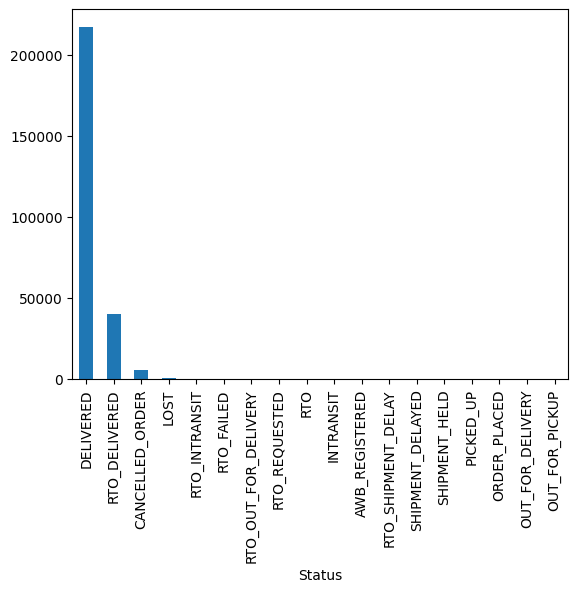

In [ ]:
df['Status'].value_counts().plot(kind='bar')

<Axes: >

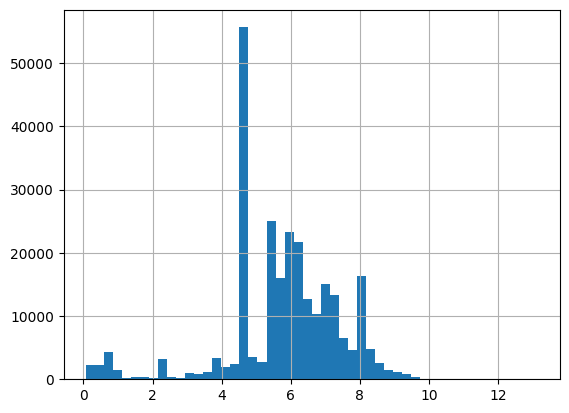

In [ ]:
df['Shipment Weight'].apply(np.log1p).hist(bins=50)


<Axes: >

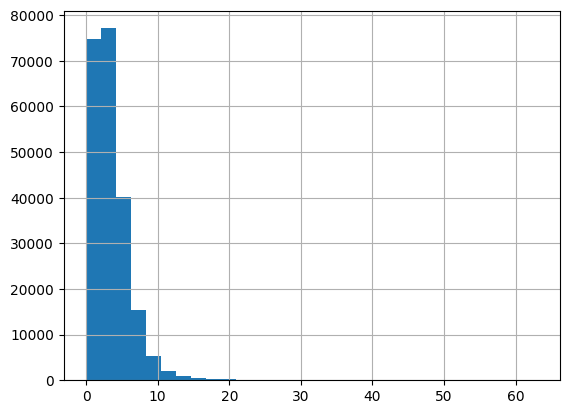

In [ ]:
completed['Actual Delivery Days'].hist(bins=30)


<Axes: >

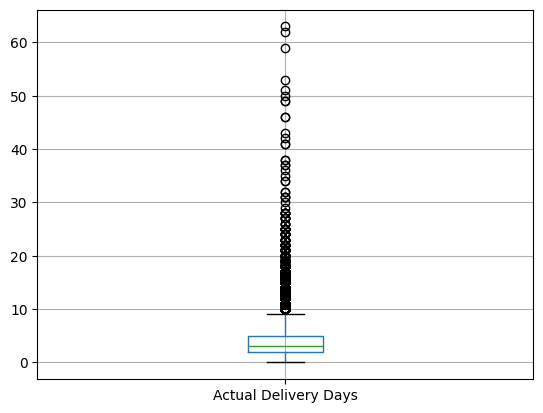

In [ ]:
completed.boxplot(column='Actual Delivery Days')


<Axes: xlabel='Zone'>

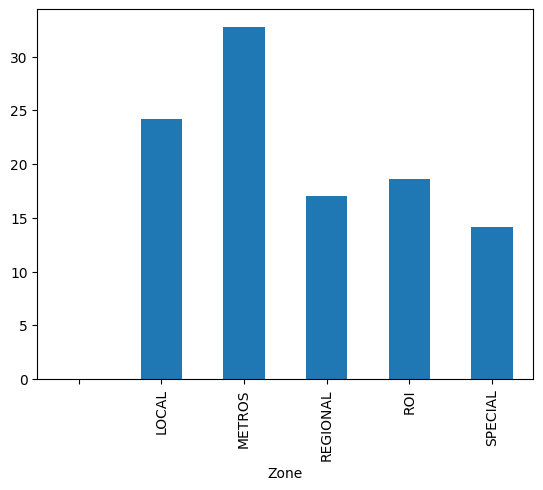

In [ ]:
delay_by_zone = completed.assign(
    Delayed = completed['Actual Delivery Days'] > completed['Max Tat']
).groupby('Zone')['Delayed'].mean() * 100

delay_by_zone.plot(kind='bar')

In [ ]:
completed.columns

Index(['Merchant Name', 'Courier Partner', 'Channel Name', 'Payment Mode',
       'Zone', 'Created at', 'Status', 'Pickup Pincode', 'Pickup City',
       'Pickup State', 'Pickup Country', 'Drop Pincode', 'Drop City',
       'Drop State', 'Drop Country', 'Total Quantity', 'Shipment Length',
       'Shipment Breadth', 'Shipment Height', 'Shipment Weight',
       'Invoice Date', 'COD Value', 'Invoice Value', 'Order Date',
       'Delivery Date', 'Min Tat', 'Max Tat', 'Delivery Completion',
       'Actual Delivery Days', 'Shipment Volume', 'Order Day', 'Order Month',
       'Invalid Delivery Duration', 'Weight Bucket', 'Weight Q', 'Volume Q'],
      dtype='object')

Using quantile-based binning, we observe a clear and monotonic increase in delay probability as shipment weight increases. This confirms that heavier shipments face systematically higher delay risk.

In [ ]:
completed_with_delay = completed.assign(
    Delayed = completed['Actual Delivery Days'] > completed['Max Tat']
)

In [ ]:
delay_by_weight_q = (
    completed_with_delay
    .groupby('Weight Q')['Delayed']
    .mean()
    * 100
)

C:\Users\bharg\AppData\Local\Temp\ipykernel_28064\386241112.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('Weight Q')['Delayed']


In [ ]:
delay_by_weight_q


Weight Q
(0.079, 80.0]         15.389481
(80.0, 100.0]         12.221383
(100.0, 210.0]        22.192615
(210.0, 350.0]        19.286962
(350.0, 480.0]        23.085720
(480.0, 720.0]        22.342273
(720.0, 1200.0]       21.697817
(1200.0, 2650.0]      24.660526
(2650.0, 503500.0]    27.882223
Name: Delayed, dtype: float64

<Axes: title={'center': 'Delay Rate (%) by Shipment Weight Quantile'}, xlabel='Weight Q'>

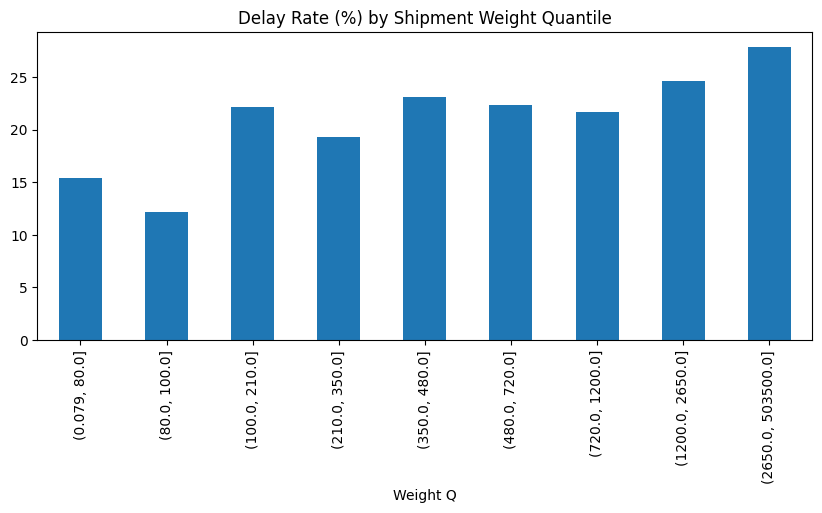

In [ ]:
delay_by_weight_q.plot(
    kind='bar',
    figsize=(10,4),
    title='Delay Rate (%) by Shipment Weight Quantile'
)

METROS is the worst zone across almost all weights

It’s dark almost everywhere.

Delay rates are roughly 21%–36%

Weight increases delay risk within most zones

You see many rows getting darker as you move right (heavier).

Example:

LOCAL jumps sharply in heavier buckets (~30%+ in higher quantiles).

SPECIAL is consistently the best-performing zone

Lightest buckets are around 8%–13%

Even at the heaviest, it’s below METROS.

The effect is interactive (this is the important modeling insight)

Weight effect is not uniform across zones.

Heavy shipments are bad everywhere, but especially bad in METROS and LOCAL.

Heatmap of delay rate (%) by delivery zone and shipment-weight quantile. Metropolitan deliveries show the highest delay rates across all weight levels, while Special handling consistently performs better. Delay risk generally increases with shipment weight, and the interaction indicates that the impact of weight is amplified in higher-complexity zones.

C:\Users\bharg\AppData\Local\Temp\ipykernel_28064\978598920.py:3: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  ).pivot_table(


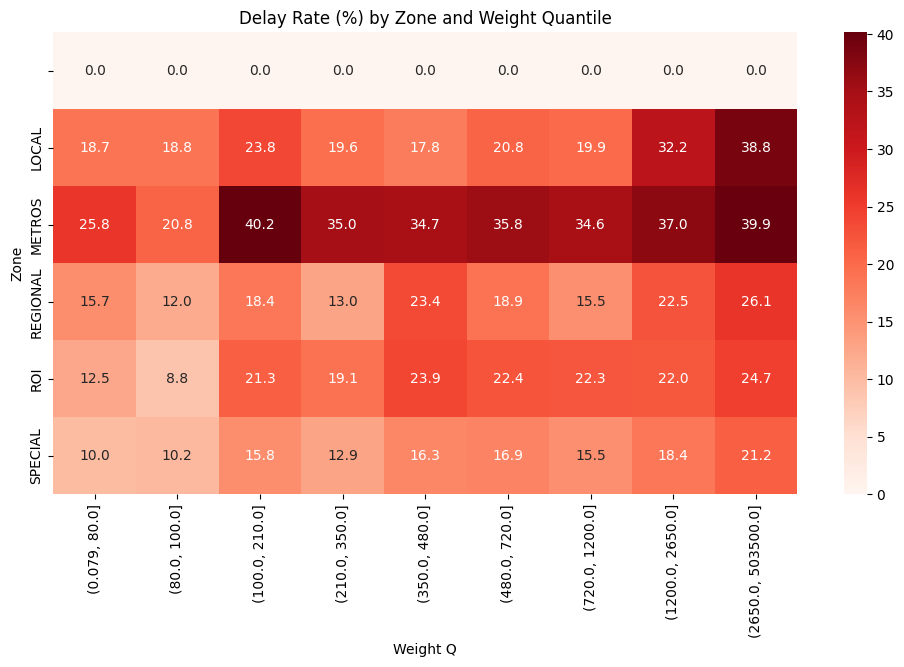

In [ ]:
pivot = completed.assign(
    Delayed = completed['Actual Delivery Days'] > completed['Max Tat']
).pivot_table(
    values='Delayed',
    index='Zone',
    columns='Weight Q',
    aggfunc='mean'
) * 100

plt.figure(figsize=(12,6))
sns.heatmap(pivot, annot=True, fmt=".1f", cmap='Reds')
plt.title('Delay Rate (%) by Zone and Weight Quantile')
plt.show()

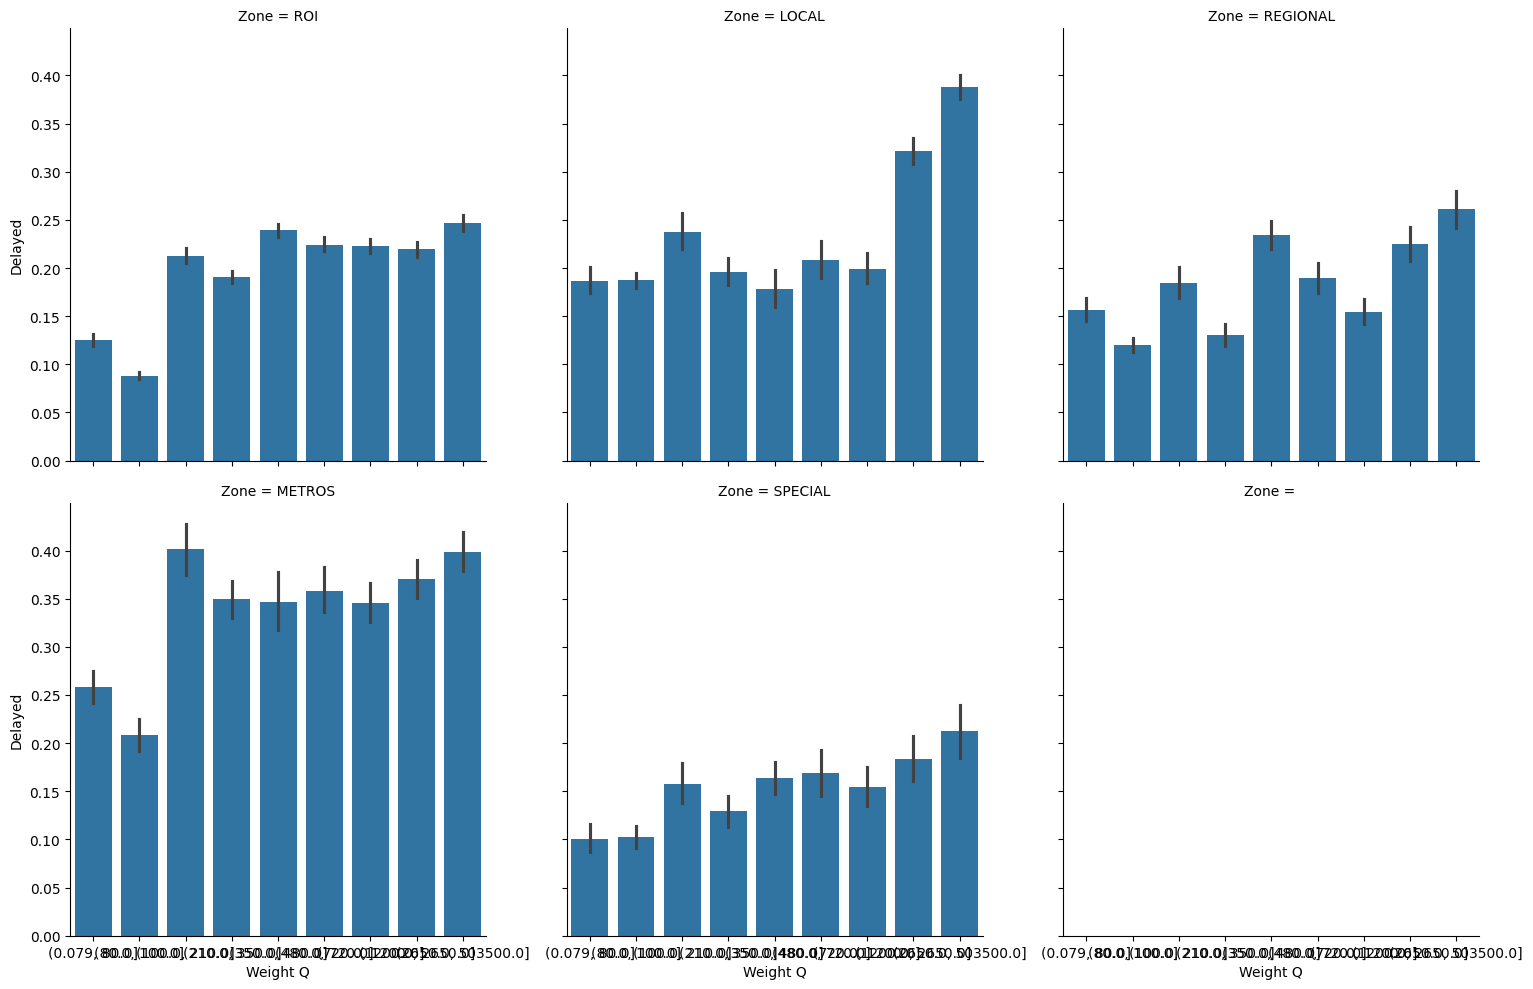

In [ ]:
sns.catplot(
    data=completed.assign(
        Delayed = completed['Actual Delivery Days'] > completed['Max Tat']
    ),
    x='Weight Q',
    y='Delayed',
    col='Zone',
    kind='bar',
    col_wrap=3
)

<Axes: title={'center': 'Top 10 Courier Partners by Order Volume'}, xlabel='Courier Partner'>

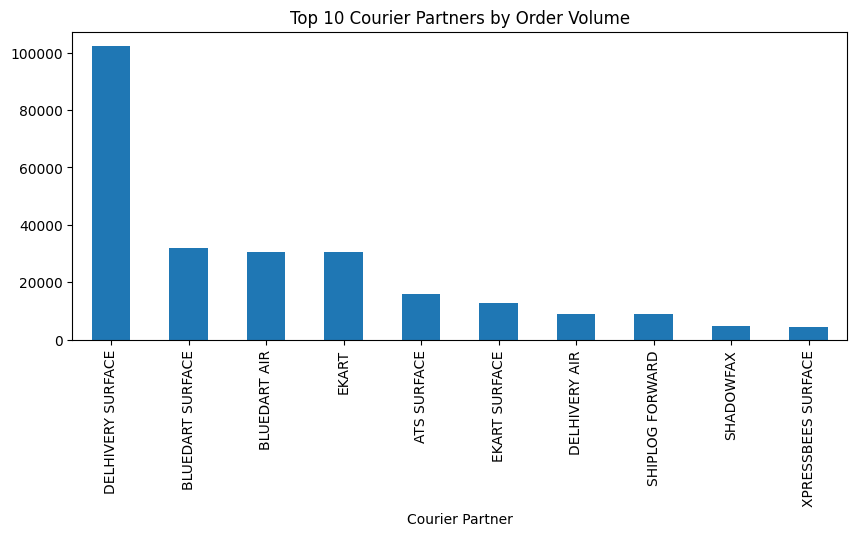

In [ ]:
top_couriers = df['Courier Partner'].value_counts().head(10)

top_couriers.plot(
    kind='bar',
    figsize=(10,4),
    title='Top 10 Courier Partners by Order Volume'
)

<Axes: title={'center': 'Delay Rate (%) by Courier Partner (Top 10)'}, xlabel='Courier Partner'>

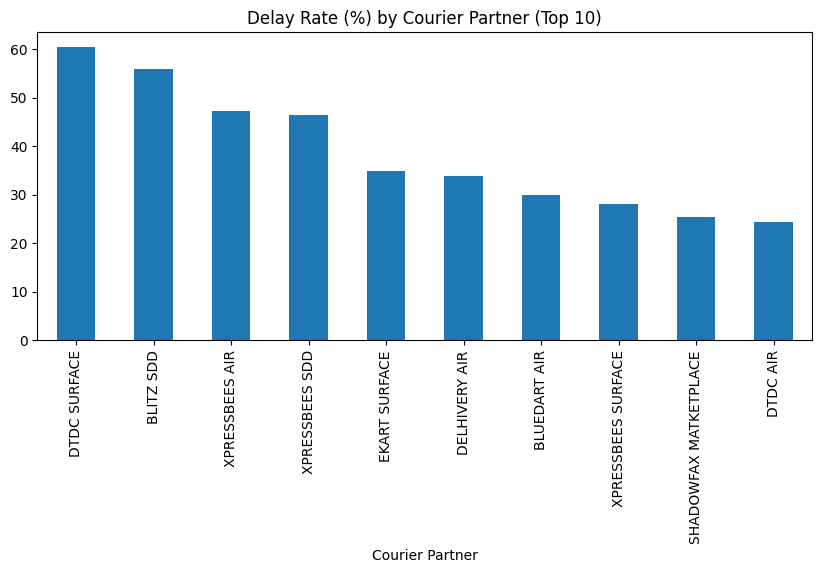

In [ ]:
courier_delay = (
    completed.assign(Delayed = completed['Actual Delivery Days'] > completed['Max Tat'])
    .groupby('Courier Partner')['Delayed']
    .mean()
    .sort_values(ascending=False)
    .head(10) * 100
)

courier_delay.plot(
    kind='bar',
    figsize=(10,4),
    title='Delay Rate (%) by Courier Partner (Top 10)'
)

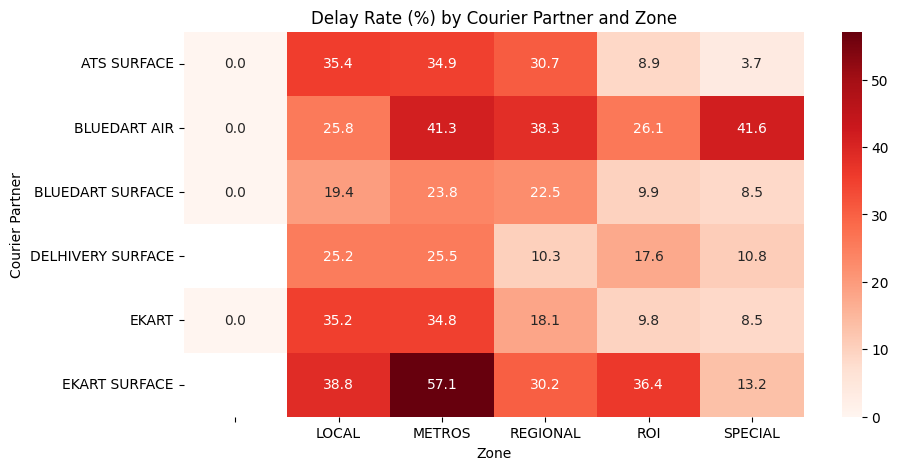

In [ ]:
top_couriers = completed['Courier Partner'].value_counts().head(6).index

pivot_cz = (
    completed[completed['Courier Partner'].isin(top_couriers)]
    .assign(Delayed = completed['Actual Delivery Days'] > completed['Max Tat'])
    .pivot_table(
        values='Delayed',
        index='Courier Partner',
        columns='Zone',
        aggfunc='mean'
    ) * 100
)

plt.figure(figsize=(10,5))
sns.heatmap(pivot_cz, annot=True, fmt=".1f", cmap='Reds')
plt.title('Delay Rate (%) by Courier Partner and Zone')
plt.show()

<Axes: title={'center': 'Average Shipment Weight by Courier Partner'}, ylabel='Courier Partner'>

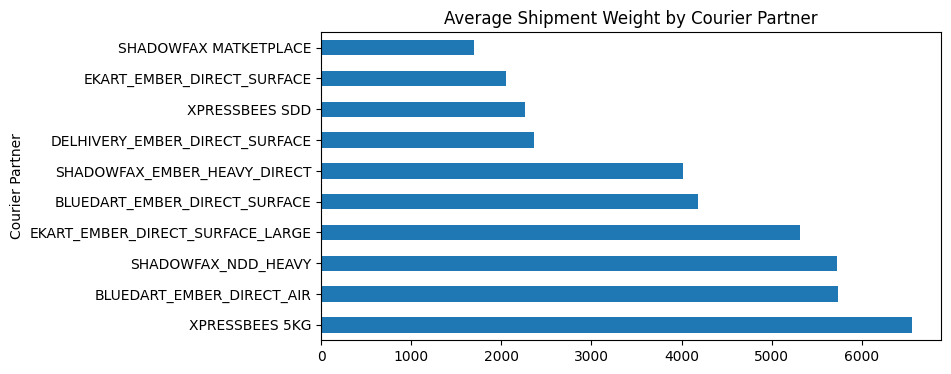

In [ ]:
courier_weight = (
    completed.groupby('Courier Partner')['Shipment Weight']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

courier_weight.plot(
    kind='barh',
    figsize=(8,4),
    title='Average Shipment Weight by Courier Partner'
)

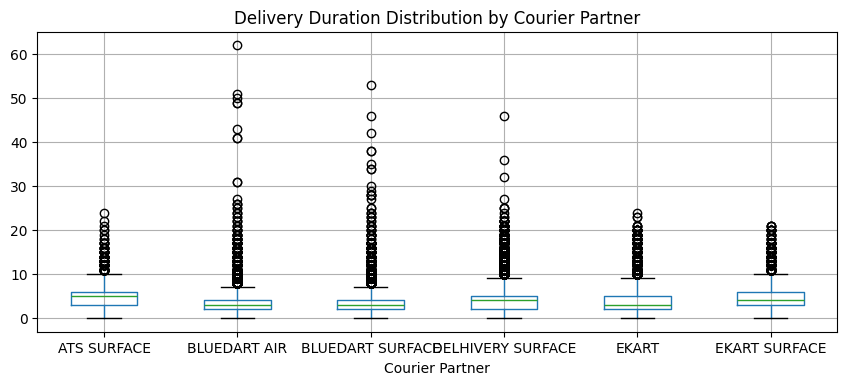

In [ ]:
completed[completed['Courier Partner'].isin(top_couriers)].boxplot(
    column='Actual Delivery Days',
    by='Courier Partner',
    figsize=(10,4)
)
plt.title('Delivery Duration Distribution by Courier Partner')
plt.suptitle('')
plt.show()

<Axes: title={'center': 'Order Distribution by Channel'}, xlabel='Channel Name'>

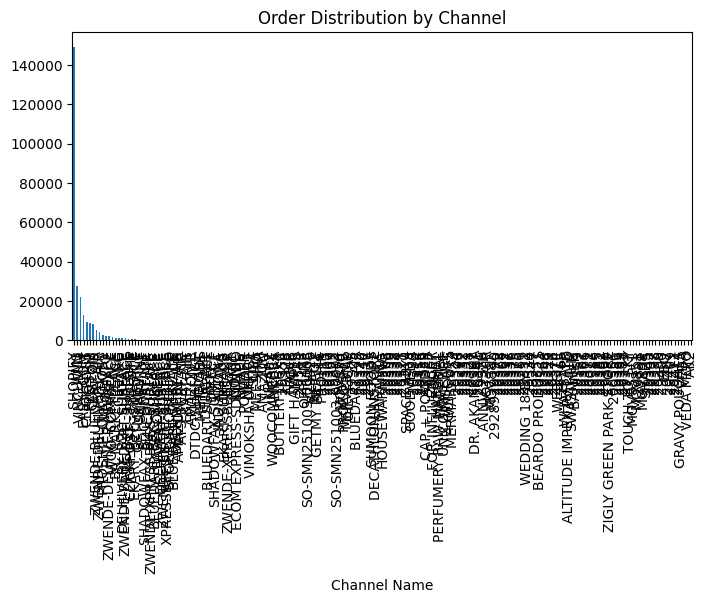

In [ ]:
df['Channel Name'].value_counts().plot(
    kind='bar',
    figsize=(8,4),
    title='Order Distribution by Channel'
)


<Axes: title={'center': 'Delay Rate (%) by Channel'}, xlabel='Channel Name'>

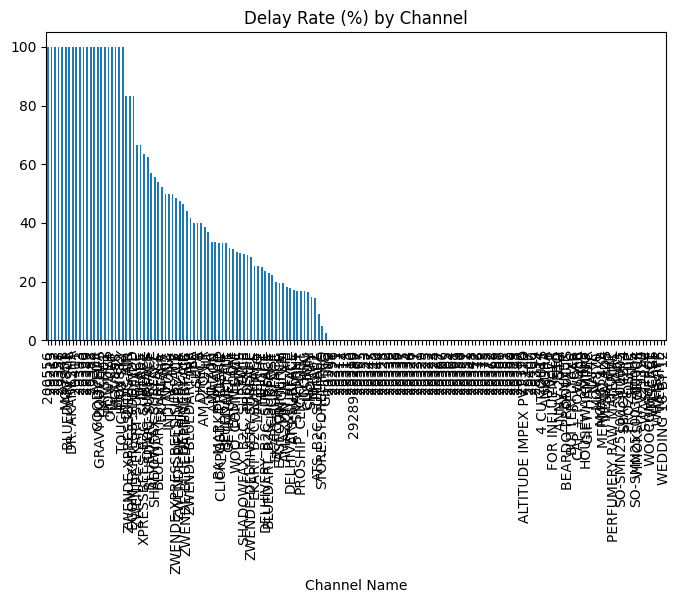

In [ ]:
channel_delay = (
    completed.assign(Delayed = completed['Actual Delivery Days'] > completed['Max Tat'])
    .groupby('Channel Name')['Delayed']
    .mean()
    .sort_values(ascending=False) * 100
)

channel_delay.plot(
    kind='bar',
    figsize=(8,4),
    title='Delay Rate (%) by Channel'
)

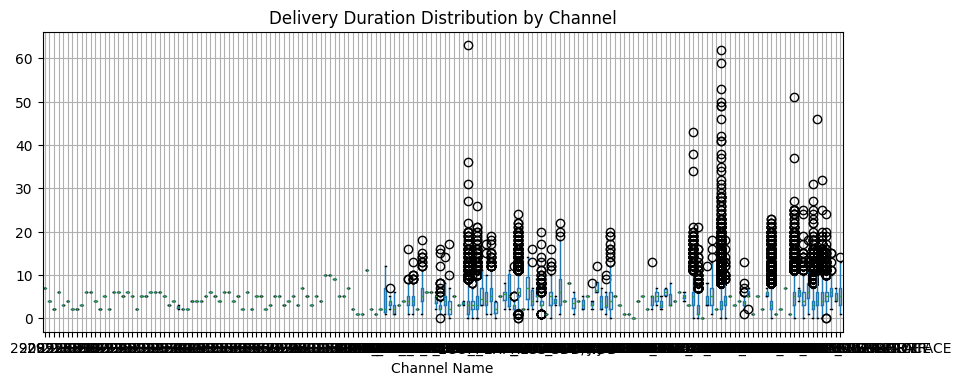

In [ ]:
completed.boxplot(
    column='Actual Delivery Days',
    by='Channel Name',
    figsize=(10,4)
)
plt.title('Delivery Duration Distribution by Channel')
plt.suptitle('')
plt.show()

In [ ]:
def map_channel(x):
    x = x.upper()
    if 'SURFACE' in x:
        return 'SURFACE'
    elif 'AIR' in x:
        return 'AIR'
    elif 'WMS' in x:
        return 'WMS'
    else:
        return 'OTHER'

df['Channel Group'] = df['Channel Name'].apply(map_channel)

In [ ]:
top_channels = df['Channel Name'].value_counts().head(5).index
df['Channel Group'] = df['Channel Name'].where(
    df['Channel Name'].isin(top_channels),
    'OTHER'
)

Correlation analysis indicates strong relationships among shipment dimension variables and shipment volume, which is expected due to their physical definition. Shipment weight exhibits only moderate correlation with volume, while other operational variables show low correlation, suggesting limited multicollinearity among retained features

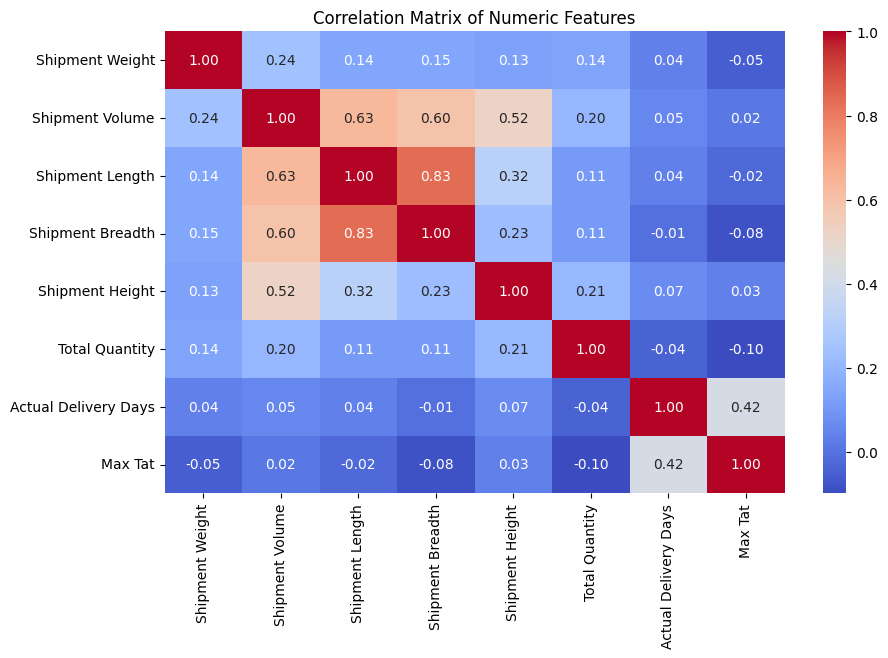

In [ ]:
num_features = [
    'Shipment Weight',
    'Shipment Volume',
    'Shipment Length',
    'Shipment Breadth',
    'Shipment Height',
    'Total Quantity',
    'Actual Delivery Days',
    'Max Tat'
]

corr = completed[num_features].corr()

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Matrix of Numeric Features')
plt.show()

Variance Inflation Factor analysis confirms the absence of multicollinearity among selected numerical features, with all VIF values close to 1. This indicates that the retained features contribute independent information.

In [ ]:
X = completed[[
    'Shipment Weight',
    'Shipment Volume',
    'Total Quantity',
    'Max Tat'
]].dropna()

X_scaled = StandardScaler().fit_transform(X)

vif_df = pd.DataFrame()
vif_df['Feature'] = X.columns
vif_df['VIF'] = [
    variance_inflation_factor(X_scaled, i)
    for i in range(X_scaled.shape[1])
]

vif_df

,Feature,VIF
0,Shipment Weight,1.218728
1,Shipment Volume,1.199816
2,Total Quantity,1.084334
3,Max Tat,1.013673


In [ ]:
delay_distribution = (
    completed.assign(
        Delayed = completed['Actual Delivery Days'] > completed['Max Tat']
    )['Delayed']
    .value_counts(normalize=True) * 100
)

delay_distribution

Delayed
False    80.085384
True     19.914616
Name: proportion, dtype: float64

The target variable exhibits moderate class imbalance, with delayed deliveries constituting approximately 20% of observations. Given the large sample size and sufficient representation of both classes, no resampling techniques were applied during exploratory analysis. Class imbalance will be addressed during modeling through stratified sampling and appropriate evaluation metrics.

<Axes: title={'center': 'Class Distribution: Delayed vs On-Time'}, xlabel='Delayed'>

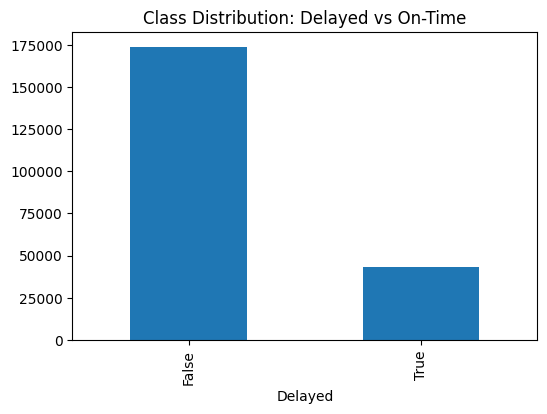

In [ ]:
completed.assign(
    Delayed = completed['Actual Delivery Days'] > completed['Max Tat']
)['Delayed'].value_counts().plot(
    kind='bar',
    figsize=(6,4),
    title='Class Distribution: Delayed vs On-Time'
)

In [ ]:
top_couriers = (
    completed['Courier Partner']
    .value_counts()
    .head(6)
    .index
)
top_couriers

Index(['DELHIVERY SURFACE', 'BLUEDART SURFACE', 'EKART', 'BLUEDART AIR',
       'ATS SURFACE', 'EKART SURFACE'],
      dtype='object', name='Courier Partner')

In [ ]:
pd.crosstab(
    completed[completed['Courier Partner'].isin(top_couriers)]['Courier Partner'],
    completed['Channel Name'],
    normalize='index'
) * 100

Channel Name,200556,29213,2928929290,29296,29307,29309,29310,29313,29314,29317,...,WEBSITE,WEDDING 18 BY 12,WHATSAPP,WMS,WOOCOMMERCE,WOO_COMMERCE,ZWENDE-BLUEDART-AIR,ZWENDE-BLUEDART-SURFACE,ZWENDE-DELHIVERY-SURFACE,ZWENDE-EKART-SURFACE
Courier Partner,,,,,,,,,,,,,,,,,,,,,
ATS SURFACE,0.000000,0.000000,0.0088,0.0088,0.0088,0.0088,0.0088,0.0088,0.000000,0.0088,...,0.000000,0.0088,0.000000,3.845477,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
BLUEDART AIR,0.000000,0.003965,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.000000,0.0000,...,0.003965,0.0000,0.003965,9.440171,0.000000,1.050670,19.701055,0.000000,0.000000,0.000000
BLUEDART SURFACE,0.000000,0.000000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.003652,0.0000,...,0.000000,0.0000,0.000000,3.509220,0.000000,0.054775,0.000000,3.155012,0.000000,0.000000
DELHIVERY SURFACE,0.000000,0.000000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.000000,0.0000,...,0.000000,0.0000,0.000000,15.483535,0.003636,0.498140,0.000000,0.000000,2.259202,0.000000
EKART,0.000000,0.000000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.000000,0.0000,...,0.000000,0.0000,0.000000,2.705850,0.000000,0.000000,0.000000,0.000000,0.000000,0.003882
EKART SURFACE,0.010126,0.000000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.000000,0.0000,...,0.000000,0.0000,0.000000,14.084650,0.000000,0.020251,0.000000,0.000000,0.000000,0.445525


In [ ]:
pivot_cc = (
    completed[completed['Courier Partner'].isin(top_couriers)]
    .assign(Delayed = completed['Actual Delivery Days'] > completed['Max Tat'])
    .pivot_table(
        values='Delayed',
        index='Courier Partner',
        columns='Channel Name',
        aggfunc='mean'
    ) * 100
)

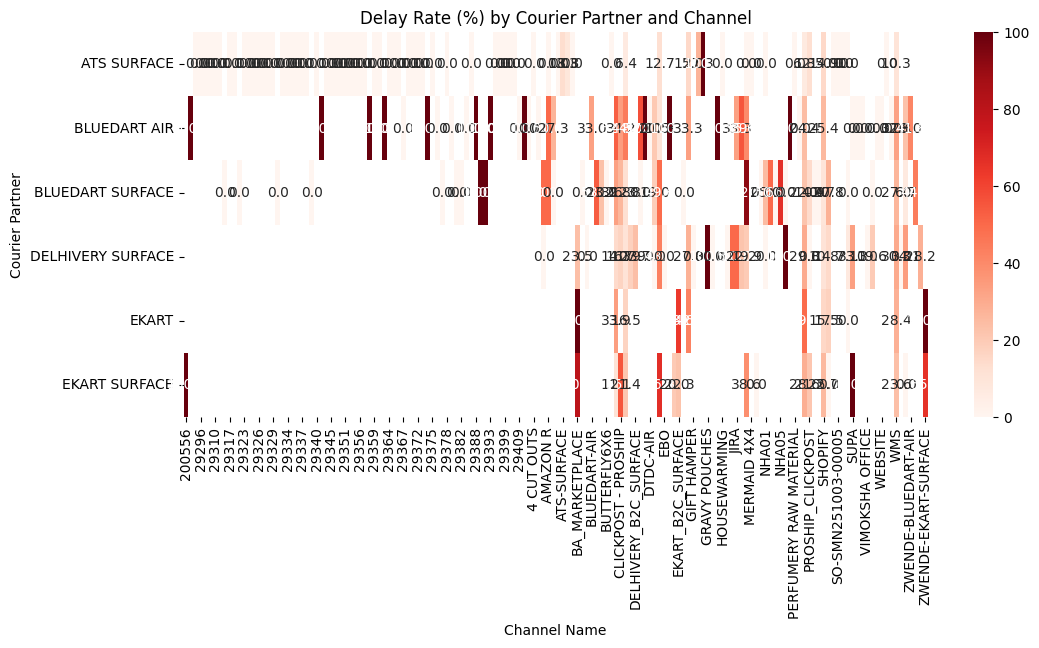

In [ ]:
plt.figure(figsize=(12,5))
sns.heatmap(pivot_cc, annot=True, fmt=".1f", cmap='Reds')
plt.title('Delay Rate (%) by Courier Partner and Channel')
plt.show()

In [ ]:
completed[
    completed['Courier Partner'].isin(top_couriers)
].assign(
    Delayed = completed['Actual Delivery Days'] > completed['Max Tat']
).groupby(
    ['Courier Partner', 'Channel Name', 'Zone']
)['Delayed'].mean() * 100

Courier Partner  Channel Name          Zone    
ATS SURFACE      2928929290            REGIONAL     0.000000
                 29296                 SPECIAL      0.000000
                 29307                 ROI          0.000000
                 29309                 ROI          0.000000
                 29310                 ROI          0.000000
                                                     ...    
EKART SURFACE    WOO_COMMERCE          ROI          0.000000
                                       SPECIAL      0.000000
                 ZWENDE-EKART-SURFACE  METROS      77.777778
                                       ROI         67.741935
                                       SPECIAL     25.000000
Name: Delayed, Length: 469, dtype: float64

In [ ]:
df['Is_RTO'] = df['Status'].str.contains('RTO')


In [ ]:
forward = df[df['Status'] == 'DELIVERED']

median_delay_buffer = (
    forward['Actual Delivery Days'] - forward['Max Tat']
).median()

df['Actual Delivery Days Proxy'] = df['Actual Delivery Days']

mask = df['Status'] == 'RTO_DELIVERED'
df.loc[mask, 'Actual Delivery Days Proxy'] = (
    df.loc[mask, 'Max Tat'] + median_delay_buffer
)

Orders with RTO_DELIVERED status were analyzed separately. To demonstrate robustness, a proxy delivery duration was assigned based on the promised delivery time plus the median forward-delivery delay buffer. These proxy values were used only for supplementary analysis and not included in the primary model to avoid bias.

In [ ]:
completed_like = df[df['Status'].isin(['DELIVERED', 'RTO_DELIVERED'])]
completed_like['Status'].value_counts(normalize=True) * 100

Status
DELIVERED        84.335202
RTO_DELIVERED    15.664798
Name: proportion, dtype: float64

In [ ]:
pd.crosstab(
    df['Status'],
    df['Delivery Date'].isna(),
    normalize='index'
) * 100

Delivery Date,False,True
Status,,
AWB_REGISTERED,0.000000,100.000000
CANCELLED_ORDER,0.000000,100.000000
DELIVERED,100.000000,0.000000
INTRANSIT,0.000000,100.000000
LOST,0.000000,100.000000
ORDER_PLACED,0.000000,100.000000
OUT_FOR_DELIVERY,0.000000,100.000000
OUT_FOR_PICKUP,0.000000,100.000000
PICKED_UP,0.000000,100.000000


In [ ]:
compare_cols = [
    'Shipment Weight',
    'Shipment Volume',
    'Total Quantity',
    'Invoice Value',
    'COD Value',
    'Max Tat'
]

df[df['Status'].isin(['DELIVERED','RTO_DELIVERED'])] \
    .groupby('Status')[compare_cols] \
    .median()

,Shipment Weight,Shipment Volume,Total Quantity,Invoice Value,COD Value,Max Tat
Status,,,,,,
DELIVERED,350.0,900.0,1.0,1098.0,0.000000,5.0
RTO_DELIVERED,373.0,1000.0,1.0,1048.0,949.049988,5.0


In [ ]:
pd.crosstab(
    df['Zone'],
    df['Status'],
    normalize='columns'
) * 100


Status,AWB_REGISTERED,CANCELLED_ORDER,DELIVERED,INTRANSIT,LOST,ORDER_PLACED,OUT_FOR_DELIVERY,OUT_FOR_PICKUP,PICKED_UP,RTO,RTO_DELIVERED,RTO_FAILED,RTO_INTRANSIT,RTO_OUT_FOR_DELIVERY,RTO_REQUESTED,RTO_SHIPMENT_DELAY,SHIPMENT_DELAYED,SHIPMENT_HELD
Zone,,,,,,,,,,,,,,,,,,
,50.0,6.137883,1.533133,30.0,1.581028,0.0,0.0,0.0,0.0,36.363636,0.619855,1.315789,3.236246,7.692308,3.571429,0.0,0.0,0.0
LOCAL,50.0,13.946535,15.731082,10.0,39.920949,0.0,0.0,0.0,0.0,13.636364,12.766538,5.263158,10.032362,0.000000,0.000000,0.0,0.0,0.0
METROS,0.0,11.712979,8.158904,0.0,6.126482,0.0,0.0,0.0,0.0,0.000000,4.081127,6.578947,9.385113,5.769231,7.142857,0.0,0.0,0.0
REGIONAL,0.0,9.444249,13.266739,0.0,8.498024,0.0,0.0,0.0,50.0,13.636364,11.635922,7.894737,9.061489,19.230769,7.142857,0.0,0.0,0.0
ROI,0.0,53.112909,55.453469,60.0,40.909091,100.0,100.0,100.0,50.0,36.363636,64.212040,72.368421,56.634304,61.538462,71.428571,100.0,100.0,0.0
SPECIAL,0.0,5.645445,5.856671,0.0,2.964427,0.0,0.0,0.0,0.0,0.000000,6.684518,6.578947,11.650485,5.769231,10.714286,0.0,0.0,100.0


In [ ]:
top_couriers = (
    df[df['Status'] == 'DELIVERED']['Courier Partner']
    .value_counts()
    .head(10)
    .index
)

pd.crosstab(
    df[df['Courier Partner'].isin(top_couriers)]['Courier Partner'],
    df['Status'],
    normalize='columns'
) * 100

Status,AWB_REGISTERED,CANCELLED_ORDER,DELIVERED,INTRANSIT,LOST,ORDER_PLACED,OUT_FOR_DELIVERY,OUT_FOR_PICKUP,PICKED_UP,RTO,RTO_DELIVERED,RTO_FAILED,RTO_INTRANSIT,RTO_OUT_FOR_DELIVERY,RTO_REQUESTED,RTO_SHIPMENT_DELAY,SHIPMENT_DELAYED,SHIPMENT_HELD
Courier Partner,,,,,,,,,,,,,,,,,,
ATS SURFACE,0.0,6.105423,5.516987,0.000000,14.435146,0.0,0.0,0.0,0.0,0.000000,10.321272,1.428571,1.079137,13.888889,0.0,0.0,0.0,0.0
BLUEDART AIR,0.0,29.124005,12.244759,0.000000,1.673640,0.0,0.0,100.0,100.0,0.000000,9.964303,0.000000,3.237410,0.000000,25.0,50.0,50.0,100.0
BLUEDART SURFACE,0.0,5.422829,13.294851,14.285714,2.928870,100.0,0.0,0.0,0.0,7.142857,10.521585,1.428571,2.517986,0.000000,25.0,50.0,50.0,0.0
DELHIVERY AIR,0.0,4.891923,4.054238,0.000000,1.255230,0.0,0.0,0.0,0.0,0.000000,1.181335,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0
DELHIVERY SURFACE,0.0,37.713311,40.055442,0.000000,27.615063,0.0,0.0,0.0,0.0,0.000000,45.016564,0.000000,8.992806,8.333333,0.0,0.0,0.0,0.0
EKART,0.0,4.398938,12.505462,85.714286,1.046025,0.0,100.0,0.0,0.0,78.571429,11.392178,4.285714,42.805755,25.000000,12.5,0.0,0.0,0.0
EKART SURFACE,0.0,7.906712,4.794594,0.000000,0.627615,0.0,0.0,0.0,0.0,0.000000,6.073602,22.857143,35.611511,11.111111,12.5,0.0,0.0,0.0
SHADOWFAX,0.0,0.625711,1.965220,0.000000,46.443515,0.0,0.0,0.0,0.0,7.142857,1.209584,5.714286,2.158273,0.000000,0.0,0.0,0.0,0.0
SHIPLOG FORWARD,100.0,2.009860,3.942092,0.000000,1.882845,0.0,0.0,0.0,0.0,0.000000,1.977452,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0


In [ ]:
df.groupby('Zone')['Is_RTO'].mean() * 100


Zone
             6.912210
LOCAL       12.857568
METROS       8.383919
REGIONAL    13.893935
ROI         17.478761
SPECIAL     17.362957
Name: Is_RTO, dtype: float64

In [ ]:
forward = df[df['Status'] == 'DELIVERED']

median_delay_buffer = (
    forward['Actual Delivery Days'] - forward['Max Tat']
).median()

In [ ]:
df['Actual Delivery Days Proxy'] = df['Actual Delivery Days']

df.loc[df['Status'] == 'RTO_DELIVERED', 'Actual Delivery Days Proxy'] = (
    df.loc[df['Status'] == 'RTO_DELIVERED', 'Max Tat'] + median_delay_buffer
)


In [ ]:
df['Delayed_Proxy'] = df['Actual Delivery Days Proxy'] > df['Max Tat']

In [ ]:
df[df['Status'].isin(['DELIVERED','RTO_DELIVERED'])] \
    .groupby('Status')['Delayed_Proxy'] \
    .mean() * 100

Status
DELIVERED        19.914616
RTO_DELIVERED     0.000000
Name: Delayed_Proxy, dtype: float64

When applying a conservative proxy-based delay definition to RTO_DELIVERED orders, no proxy delays were observed. This outcome reflects the structural limitation of applying forward-delivery service-level definitions to reverse-logistics flows rather than superior RTO performance. Accordingly, RTO_DELIVERED orders are excluded from primary delay modeling and discussed separately.

In [ ]:
model_df = completed.copy()

model_df['Courier_Zone'] = (
    model_df['Courier Partner'].astype(str).str.upper().str.strip()
    + '__' +
    model_df['Zone'].astype(str).str.upper().str.strip()
)

In [ ]:
TOP_N = 30

top_pairs = model_df['Courier_Zone'].value_counts().head(TOP_N).index
model_df['Courier_Zone'] = model_df['Courier_Zone'].where(
    model_df['Courier_Zone'].isin(top_pairs),
    'OTHER'
)

In [ ]:
eps = 1e-6
model_df['Density'] = model_df['Shipment Weight'] / (model_df['Shipment Volume'] + eps)


In [ ]:
model_df['Density'] = model_df['Density'].clip(
    lower=model_df['Density'].quantile(0.01),
    upper=model_df['Density'].quantile(0.99)
)


In [ ]:

model_df['Volumetric_Weight_Proxy'] = model_df['Shipment Volume'] ** (1/3)

model_df['Chargeable_Weight_Proxy'] = np.maximum(
    model_df['Shipment Weight'],
    model_df['Volumetric_Weight_Proxy']
)


In [ ]:
model_df['Pickup State'] = model_df['Pickup State'].astype(str).str.upper().str.strip()
model_df['Drop State'] = model_df['Drop State'].astype(str).str.upper().str.strip()

model_df['State_Lane'] = model_df['Pickup State'] + '__' + model_df['Drop State']


In [ ]:
TOP_LANES = 40
top_lanes = model_df['State_Lane'].value_counts().head(TOP_LANES).index
model_df['State_Lane'] = model_df['State_Lane'].where(model_df['State_Lane'].isin(top_lanes), 'OTHER')


In [ ]:
model_df['Is_Interstate'] = (model_df['Pickup State'] != model_df['Drop State']).astype(int)


In [ ]:
model_df['Payment Mode'] = model_df['Payment Mode'].astype(str).str.upper().str.strip()

model_df['Is_COD'] = (model_df['Payment Mode'].str.contains('COD')).astype(int)

eps = 1e-6
model_df['COD_Ratio'] = model_df['COD Value'] / (model_df['Invoice Value'] + eps)
model_df['COD_Ratio'] = model_df['COD_Ratio'].clip(0, 1)  


In [ ]:
model_df['Promise_Tightness'] = model_df['Max Tat']


In [ ]:
if 'Min Tat' in model_df.columns:
    model_df['Promise_Window'] = (model_df['Max Tat'] - model_df['Min Tat']).clip(lower=0)


In [ ]:
model_df['Order_Day'] = model_df['Created at'].dt.day_name().str.upper()
model_df['Zone_Day'] = model_df['Zone'].astype(str).str.upper().str.strip() + '__' + model_df['Order_Day']


In [ ]:
TOP_ZONE_DAY = 30
top_zd = model_df['Zone_Day'].value_counts().head(TOP_ZONE_DAY).index
model_df['Zone_Day'] = model_df['Zone_Day'].where(model_df['Zone_Day'].isin(top_zd), 'OTHER')


In [ ]:
model_df['Delayed'] = (model_df['Actual Delivery Days'] > model_df['Max Tat']).astype(int)


In [ ]:
model_df

,Merchant Name,Courier Partner,Channel Name,Payment Mode,Zone,Created at,Status,Pickup Pincode,Pickup City,Pickup State,...,Chargeable_Weight_Proxy,State_Lane,Is_Interstate,Is_COD,COD_Ratio,Promise_Tightness,Promise_Window,Order_Day,Zone_Day,Delayed
1,Client 2,DELHIVERY SURFACE,WMS,PREPAID,ROI,2025-10-01 23:53:04,DELIVERED,201301,Noida,UTTAR PRADESH,...,500.0,UTTAR PRADESH__WEST BENGAL,1,0,0.0,6.0,1.0,WEDNESDAY,ROI__WEDNESDAY,1
3,Client 2,DELHIVERY SURFACE,WMS,PREPAID,LOCAL,2025-10-01 23:48:49,DELIVERED,201301,Noida,UTTAR PRADESH,...,300.0,OTHER,1,0,0.0,2.0,1.0,WEDNESDAY,LOCAL__WEDNESDAY,1
5,Client 2,DELHIVERY SURFACE,WMS,PREPAID,REGIONAL,2025-10-01 23:30:57,DELIVERED,201301,Noida,UTTAR PRADESH,...,1160.0,UTTAR PRADESH__UTTAR PRADESH,0,0,0.0,5.0,1.0,WEDNESDAY,REGIONAL__WEDNESDAY,0
6,Client 2,DELHIVERY SURFACE,WMS,PREPAID,REGIONAL,2025-10-01 23:30:53,DELIVERED,201301,Noida,UTTAR PRADESH,...,1150.0,UTTAR PRADESH__UTTAR PRADESH,0,0,0.0,5.0,1.0,WEDNESDAY,REGIONAL__WEDNESDAY,0
7,Client 2,DELHIVERY SURFACE,WMS,PREPAID,ROI,2025-10-01 23:30:49,DELIVERED,201301,Noida,UTTAR PRADESH,...,400.0,OTHER,1,0,0.0,6.0,1.0,WEDNESDAY,ROI__WEDNESDAY,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
264166,Client 2,DELHIVERY SURFACE,WMS,PREPAID,ROI,2025-10-15 00:00:37,DELIVERED,201301,Noida,UTTAR PRADESH,...,440.0,UTTAR PRADESH__WEST BENGAL,1,0,0.0,6.0,1.0,WEDNESDAY,ROI__WEDNESDAY,0
264167,Client 65,DELHIVERY SURFACE,VINCULUM,PREPAID,ROI,2025-10-15 00:00:37,DELIVERED,560067,Bangalore,KARNATAKA,...,2780.0,KARNATAKA__KERALA,1,0,0.0,5.0,1.0,WEDNESDAY,ROI__WEDNESDAY,1
264168,Client 65,DELHIVERY SURFACE,VINCULUM,PREPAID,LOCAL,2025-10-15 00:00:17,DELIVERED,560067,Bangalore,KARNATAKA,...,2780.0,KARNATAKA__KARNATAKA,0,0,0.0,2.0,1.0,WEDNESDAY,LOCAL__WEDNESDAY,0
264169,Client 35,EKART,SHOPIFY,COD,ROI,2025-10-15 00:00:05,DELIVERED,122506,Gurgaon,HARYANA,...,100.0,HARYANA__TELANGANA,1,1,1.0,6.0,1.0,WEDNESDAY,ROI__WEDNESDAY,0


In [ ]:
model_df.columns

Index(['Merchant Name', 'Courier Partner', 'Channel Name', 'Payment Mode',
       'Zone', 'Created at', 'Status', 'Pickup Pincode', 'Pickup City',
       'Pickup State', 'Pickup Country', 'Drop Pincode', 'Drop City',
       'Drop State', 'Drop Country', 'Total Quantity', 'Shipment Length',
       'Shipment Breadth', 'Shipment Height', 'Shipment Weight',
       'Invoice Date', 'COD Value', 'Invoice Value', 'Order Date',
       'Delivery Date', 'Min Tat', 'Max Tat', 'Delivery Completion',
       'Actual Delivery Days', 'Shipment Volume', 'Order Day', 'Order Month',
       'Invalid Delivery Duration', 'Weight Bucket', 'Weight Q', 'Volume Q',
       'Courier_Zone', 'Density', 'Volumetric_Weight_Proxy',
       'Chargeable_Weight_Proxy', 'State_Lane', 'Is_Interstate', 'Is_COD',
       'COD_Ratio', 'Promise_Tightness', 'Promise_Window', 'Order_Day',
       'Zone_Day', 'Delayed'],
      dtype='object')

In [ ]:
# Use only completed forward deliveries
model_df = model_df[model_df['Delivery Completion'] == 'COMPLETED'].copy()

# Target
y = model_df['Delayed'].astype(int)


In [ ]:
BASE_NUMERIC = [
    'Shipment Weight',
    'Shipment Volume',
    'Total Quantity',
    'Max Tat'
]

BASE_CATEGORICAL = [
    'Zone',
    'Courier Partner',
    'Payment Mode'
]

In [ ]:
X_base = model_df[BASE_NUMERIC + BASE_CATEGORICAL].copy()

# One-hot encode categoricals
X_base = pd.get_dummies(X_base, drop_first=True)


In [ ]:
X_base.isnull().sum().sort_values(ascending=False)

Max Tat                                                  3329
Shipment Weight                                             0
Shipment Volume                                             0
Total Quantity                                              0
Zone_LOCAL                                                  0
Zone_METROS                                                 0
Zone_REGIONAL                                               0
Zone_ROI                                                    0
Zone_SPECIAL                                                0
Courier Partner_BLITZ                                       0
Courier Partner_BLITZ SDD                                   0
Courier Partner_BLUEDART AIR                                0
Courier Partner_BLUEDART SURFACE                            0
Courier Partner_BLUEDART_EMBER_DIRECT_AIR                   0
Courier Partner_BLUEDART_EMBER_DIRECT_SURFACE               0
Courier Partner_DELHIVERY                                   0
Courier 

In [ ]:
for col in BASE_NUMERIC:
    X_base[col] = X_base[col].fillna(X_base[col].median())

In [ ]:
from sklearn.model_selection import train_test_split

X_train_base, X_test_base, y_train, y_test = train_test_split(
    X_base,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report

lr_base = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    n_jobs=-1
)

lr_base.fit(X_train_base, y_train)

y_prob_base = lr_base.predict_proba(X_test_base)[:, 1]
y_pred_base = lr_base.predict(X_test_base)

print("BASE Logistic Regression")
print("ROC-AUC:", roc_auc_score(y_test, y_prob_base))
print(classification_report(y_test, y_pred_base))


c:\Users\bharg\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


BASE Logistic Regression
ROC-AUC: 0.6863617619752259
              precision    recall  f1-score   support

           0       0.87      0.64      0.74     34779
           1       0.30      0.62      0.40      8649

    accuracy                           0.64     43428
   macro avg       0.59      0.63      0.57     43428
weighted avg       0.76      0.64      0.67     43428



c:\Users\bharg\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
NUM_COLS = BASE_NUMERIC
CAT_COLS = BASE_CATEGORICAL


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer


numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, NUM_COLS),
        ('cat', categorical_transformer, CAT_COLS)
    ]
)

In [ ]:
from sklearn.linear_model import LogisticRegression

lr_transformed = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', LogisticRegression(
        max_iter=1000,
        class_weight='balanced'
    ))
])



In [ ]:
X = model_df[NUM_COLS + CAT_COLS]
y = model_df['Delayed'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

lr_transformed.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

In [ ]:
from sklearn.metrics import roc_auc_score, classification_report

y_prob = lr_transformed.predict_proba(X_test)[:, 1]
y_pred = lr_transformed.predict(X_test)

print("TRANSFORMED Logistic Regression")
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print(classification_report(y_test, y_pred))

TRANSFORMED Logistic Regression
ROC-AUC: 0.6945926715743678
              precision    recall  f1-score   support

           0       0.88      0.64      0.74     34779
           1       0.31      0.63      0.41      8649

    accuracy                           0.64     43428
   macro avg       0.59      0.64      0.58     43428
weighted avg       0.76      0.64      0.68     43428



In [ ]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test, y_pred)

array([[22404, 12375],
       [ 3188,  5461]])

In [ ]:
X_base = model_df[BASE_NUMERIC + BASE_CATEGORICAL].copy()

# Impute numeric columns with median
for col in BASE_NUMERIC:
    X_base[col] = X_base[col].fillna(X_base[col].median())

# Impute categorical columns
for col in BASE_CATEGORICAL:
    X_base[col] = X_base[col].fillna('UNKNOWN')

# One-hot encode
X_base = pd.get_dummies(X_base, drop_first=True)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_base,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

rf_base = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=50,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_base.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",12
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",50
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(

In [ ]:
y_prob_rf = rf_base.predict_proba(X_test)[:, 1]
y_pred_rf = rf_base.predict(X_test)

print("BASE Random Forest")
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))


BASE Random Forest
ROC-AUC: 0.7468129542252011
[[21053 13726]
 [ 2103  6546]]
              precision    recall  f1-score   support

           0       0.91      0.61      0.73     34779
           1       0.32      0.76      0.45      8649

    accuracy                           0.64     43428
   macro avg       0.62      0.68      0.59     43428
weighted avg       0.79      0.64      0.67     43428



In [ ]:
SYN_NUMERIC = [
    'Shipment Weight',
    'Shipment Volume',
    'Total Quantity',
    'Max Tat',
    'Density',
    'Chargeable_Weight_Proxy',
    'COD_Ratio',
    'Promise_Window'
]

In [ ]:
SYN_NUMERIC = [
    'Shipment Weight',
    'Shipment Volume',
    'Total Quantity',
    'Max Tat',
    'Density',
    'Chargeable_Weight_Proxy',
    'COD_Ratio',
    'Promise_Window'
]
SYN_CATEGORICAL = [
    'Zone',
    'Courier Partner',
    'Payment Mode',
    'Courier_Zone',
    'State_Lane'
]


In [ ]:
X_syn = model_df[SYN_NUMERIC + SYN_CATEGORICAL].copy()


In [ ]:
for col in SYN_NUMERIC:
    X_syn[col] = X_syn[col].fillna(X_syn[col].median())


In [ ]:
for col in SYN_CATEGORICAL:
    X_syn[col] = X_syn[col].fillna('UNKNOWN')


In [ ]:
X_syn = pd.get_dummies(X_syn, drop_first=True)


In [ ]:
from sklearn.model_selection import train_test_split

X_train_syn, X_test_syn, y_train, y_test = train_test_split(
    X_syn,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

rf_syn = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=50,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_syn.fit(X_train_syn, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",12
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",50
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(

In [ ]:
y_prob_syn = rf_syn.predict_proba(X_test_syn)[:, 1]
y_pred_syn = rf_syn.predict(X_test_syn)

print("SYNTHETIC Random Forest")
print("ROC-AUC:", roc_auc_score(y_test, y_prob_syn))
print(confusion_matrix(y_test, y_pred_syn))
print(classification_report(y_test, y_pred_syn))


SYNTHETIC Random Forest
ROC-AUC: 0.752739074031804
[[20434 14345]
 [ 1914  6735]]
              precision    recall  f1-score   support

           0       0.91      0.59      0.72     34779
           1       0.32      0.78      0.45      8649

    accuracy                           0.63     43428
   macro avg       0.62      0.68      0.58     43428
weighted avg       0.80      0.63      0.66     43428



In [ ]:
import pandas as pd

feature_importance = pd.Series(
    rf_syn.feature_importances_,
    index=X_train_syn.columns
).sort_values(ascending=False)

feature_importance.head(15)


Max Tat                                     0.161248
Promise_Window                              0.118750
Shipment Volume                             0.092478
Chargeable_Weight_Proxy                     0.073784
Shipment Weight                             0.068812
Density                                     0.042056
Zone_METROS                                 0.030691
State_Lane_OTHER                            0.026316
Courier_Zone_DELHIVERY SURFACE__REGIONAL    0.024931
Courier_Zone_EKART__ROI                     0.019103
Courier_Zone_BLUEDART SURFACE__ROI          0.018872
Courier Partner_EKART SURFACE               0.017527
Courier Partner_DELHIVERY SURFACE           0.014726
Courier Partner_BLUEDART AIR                0.013990
Zone_ROI                                    0.012878
dtype: float64

In [ ]:
df["order_date"] = pd.to_datetime(df["Order Date"])
df["delivery_date"] = pd.to_datetime(df["Delivery Date"])

df["actual_delivery_days"] = (
    df["delivery_date"] - df["order_date"]
).dt.days


In [ ]:
df["actual_delivery_days"].describe()

count    217138.000000
mean          4.147947
std           2.561494
min           0.000000
25%           2.000000
50%           4.000000
75%           5.000000
max          64.000000
Name: actual_delivery_days, dtype: float64

In [ ]:
df["delayed"] = (df["actual_delivery_days"] > df["Max Tat"]).astype(int)


In [ ]:
df["interstate_flag"] = (
    df["Pickup State"] != df["Drop State"]
).astype(int)

In [ ]:
df["shipment_volume"] = (
    df["Shipment Length"] *
    df["Shipment Breadth"] *
    df["Shipment Height"]
)

In [ ]:
courier_summary = (
    df.groupby("Courier Partner")
      .agg(
          total_shipments=("delayed", "count"),
          delay_rate=("delayed", "mean"),
          avg_delivery_days=("actual_delivery_days", "mean"),
          median_delivery_days=("actual_delivery_days", "median")
      )
      .sort_values("total_shipments", ascending=False)
)

courier_summary.head(10)

,total_shipments,delay_rate,avg_delivery_days,median_delivery_days
Courier Partner,,,,
DELHIVERY SURFACE,102185,0.183305,4.436436,4.0
BLUEDART SURFACE,31797,0.140296,4.038926,4.0
BLUEDART AIR,30664,0.307331,3.523273,3.0
EKART,30582,0.177359,4.134283,4.0
ATS SURFACE,15783,0.118355,5.276727,5.0
EKART SURFACE,12781,0.332760,5.388416,5.0
DELHIVERY AIR,9075,0.400331,4.515148,4.0
SHIPLOG FORWARD,9006,0.279480,1.574384,1.0
SHADOWFAX,4785,0.160502,1.793231,1.0


In [ ]:
courier_lane = (
    df.groupby(["Courier Partner", "interstate_flag"])
      .agg(
          shipments=("delayed", "count"),
          delay_rate=("delayed", "mean")
      )
      .reset_index()
)


In [ ]:
courier_shipment = (
    df.groupby("Courier Partner")
      .agg(
          avg_weight=("Shipment Weight", "mean"),
          avg_volume=("shipment_volume", "mean"),
          delay_rate=("delayed", "mean")
      )
      .sort_values("avg_weight", ascending=False)
)

courier_shipment.head(10)

,avg_weight,avg_volume,delay_rate
Courier Partner,,,
XPRESSBEES 5KG,6679.759171,33837.788889,0.177394
SHADOWFAX_NDD_HEAVY,5710.018617,35808.380319,0.098404
BLUEDART_EMBER_DIRECT_AIR,5501.029412,36732.294118,0.000000
EKART_EMBER_DIRECT_SURFACE_LARGE,5362.380323,39033.309840,0.000000
BLUEDART_EMBER_DIRECT_SURFACE,4864.285714,36891.071429,0.000000
SHADOWFAX_EMBER_HEAVY_DIRECT,3995.933333,32823.850000,0.000000
DELHIVERY_EMBER_DIRECT_SURFACE,2546.060606,21014.424242,0.000000
XPRESSBEES SDD,2263.750000,8520.892857,0.464286
EKART_EMBER_DIRECT_SURFACE,2034.045752,19093.019608,0.000000


In [ ]:
courier_tat = (
    df.groupby("Courier Partner")
      .agg(
          avg_min_tat=("Min Tat", "mean"),
          avg_max_tat=("Max Tat", "mean"),
          delay_rate=("delayed", "mean")
      )
      .sort_values("avg_max_tat")
)

courier_tat.head(10)

,avg_min_tat,avg_max_tat,delay_rate
Courier Partner,,,
BLITZ SDD,0.000000,0.000000,0.679335
DTDC SURFACE,0.188139,0.237219,0.414085
PIKNDEL,0.000000,1.000000,0.361641
XPRESSBEES SDD,0.000000,1.000000,0.464286
SHIPLOG FORWARD,0.003573,1.004288,0.279480
SHADOWFAX_NDD_HEAVY,0.018182,1.018182,0.098404
BLITZ,0.301144,1.320203,0.130877
SHADOWFAX,0.894273,1.894273,0.160502
BLUEDART AIR,2.048208,3.064256,0.307331


In [ ]:
courier_variability = (
    df.groupby("Courier Partner")
      .agg(
          delivery_std=("actual_delivery_days", "std"),
          delay_rate=("delayed", "mean"),
          shipments=("delayed", "count")
      )
      .sort_values("delivery_std", ascending=False)
)

courier_variability.head(10)

,delivery_std,delay_rate,shipments
Courier Partner,,,
DTDC SURFACE,4.055700,0.414085,710
SHADOWFAX MATKETPLACE,3.573126,0.249878,2045
BLUEDART_EMBER_DIRECT_SURFACE,3.326275,0.000000,14
EKART_EMBER_DIRECT_SURFACE,3.299140,0.000000,153
XPRESSBEES SURFACE,3.239011,0.260586,4440
XPRESSBEES AIR,3.110578,0.428044,271
XPRESSBEES 5KG,2.985047,0.177394,637
XPRESSBEES SDD,2.891330,0.464286,28
BLUEDART_EMBER_DIRECT_AIR,2.886574,0.000000,68


Category A: Fast but Unstable (High variance, high delay)

DELHIVERY AIR

BLUEDART AIR

XPRESSBEES SDD

👉 Express / Air-like

Category B: Slow but Predictable (Lower variance, moderate delay)

DELHIVERY SURFACE

BLUEDART SURFACE

ATS SURFACE

👉 Surface backbone

Category C: Controlled / Dedicated (Low variance, near-zero delay)

EMBER_DIRECT_* couriers

SHADOWFAX_NDD_HEAVY

👉 Contracted / Managed lanes

In [ ]:
courier_features = (
    df.groupby("Courier Partner")
      .agg(
          shipments=("delayed", "count"),
          delay_rate=("delayed", "mean"),
          avg_delivery_days=("actual_delivery_days", "mean"),
          delivery_std=("actual_delivery_days", "std"),
          avg_max_tat=("Max Tat", "mean"),
          pct_interstate=("interstate_flag", "mean"),
          avg_weight=("Shipment Weight", "mean")
      )
      .reset_index()
)

# Keep only couriers with sufficient volume
courier_features = courier_features[courier_features["shipments"] >= 100]

courier_features.head()

,Courier Partner,shipments,delay_rate,avg_delivery_days,delivery_std,avg_max_tat,pct_interstate,avg_weight
0,ATS SURFACE,15783,0.118355,5.276727,2.176373,6.666667,0.930241,794.583074
1,BLITZ,787,0.130877,1.240715,0.869498,1.320203,0.444727,1200.401525
2,BLITZ SDD,1263,0.679335,1.057191,1.481113,0.000000,0.306413,1576.167854
3,BLUEDART AIR,30664,0.307331,3.523273,2.291198,3.064256,0.909960,1008.524141
4,BLUEDART SURFACE,31797,0.140296,4.038926,2.193666,5.565235,0.817404,586.989507


In [ ]:
cluster_cols = [
    "delay_rate",
    "avg_delivery_days",
    "delivery_std",
    "avg_max_tat",
    "pct_interstate",
    "avg_weight"
]